In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=Warning)

# 1. Node Embedding-based (VGAE) Link Prediction
- VGAE (Variational Graph Autoencoder)

In [2]:
# 1. library
import torch

find_links = f"https://data.pyg.org/whl/torch-{torch.__version__}.html"

!pip install -q \
    torch-scatter \
    torch-sparse \
    torch-cluster \
    torch-spline-conv \
    torch-geometric \
    -f $find_links

# seed set
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.cuda.manual_seed_all(0)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Installation Complete.")

Installation Complete.


# Cora Data Loading

In [3]:
# Cora dataset, papers as nodes and their citations as edges
# Import the Planetoid dataset class from PyTorch Geometric
from torch_geometric.datasets import Planetoid

# Loading Cora dataset
# Graph Data Download by Planetoid
cora_dataset = Planetoid(root="./cora_data", name="Cora")
cora_data = cora_dataset[0] # Get the first (and only) graph in the dataset

print("Cora Dataset Information")
print(f"Cora Dataset: {cora_dataset}")
print(f"  Nodes: {cora_data.num_nodes}") # papers
print(f"  Features: {cora_dataset.num_features}") # 1433 features
print(f"  Classes: {cora_dataset.num_classes}") # 7 classes
print(f"  Edges: {cora_data.num_edges}") # citation

Cora Dataset Information
Cora Dataset: Cora()
  Nodes: 2708
  Features: 1433
  Classes: 7
  Edges: 10556


# Cora Data spliting and transformation 

In [4]:
# data spliting and transformation 

import torch
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid # 추가: Planetoid 불러오기

np.random.seed(0)
torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define a pipeline of transformations applied to the graph data
transform = T.Compose([
    T.NormalizeFeatures(), # features Normalization to 0~1
    T.ToDevice(device),

    # Split the edges for Link Prediction tasks
    # num_val=0.05: 5% of edges used for validation, num_test=0.1: 10% of edges used for testing
    # is_undirected=True: The graph edges are bidirectional
    # split_labels=True: Create separate positive and negative edge labels
    # add_negative_train_samples=False: negative edges samples are changed 
    # at each training preventing overfitting to a fixed set of negative edges
    T.RandomLinkSplit(num_val=0.05, num_test=0.1, 
                      is_undirected=True, split_labels=True, add_negative_train_samples=False),
])

cora_dataset_transformed = Planetoid(root='./cora_data', name='Cora', transform=transform)
# Random Link Split
train_data, val_data, test_data = cora_dataset_transformed[0]

print("Train features:", train_data.num_features)
print("Train real edges 85%:", train_data.edge_index.shape[1])

print("\nVal features:", train_data.num_features)
print("Val (marked) real edges 5%:", val_data.pos_edge_label_index.shape[1])
print("Val (generated) fake edges 5%:", val_data.neg_edge_label_index.shape[1])

print("\nTest features:", test_data.num_features)
print("Test (marked) real edges 10%:", test_data.pos_edge_label_index.shape[1])
print("Test (generated) fake edges 10%:", test_data.neg_edge_label_index.shape[1])

Train features: 1433
Train real edges 85%: 8976

Val features: 1433
Val (marked) real edges 5%: 263
Val (generated) fake edges 5%: 263

Test features: 1433
Test (marked) real edges 10%: 527
Test (generated) fake edges 10%: 527


# Visualization of Link Prediction Data

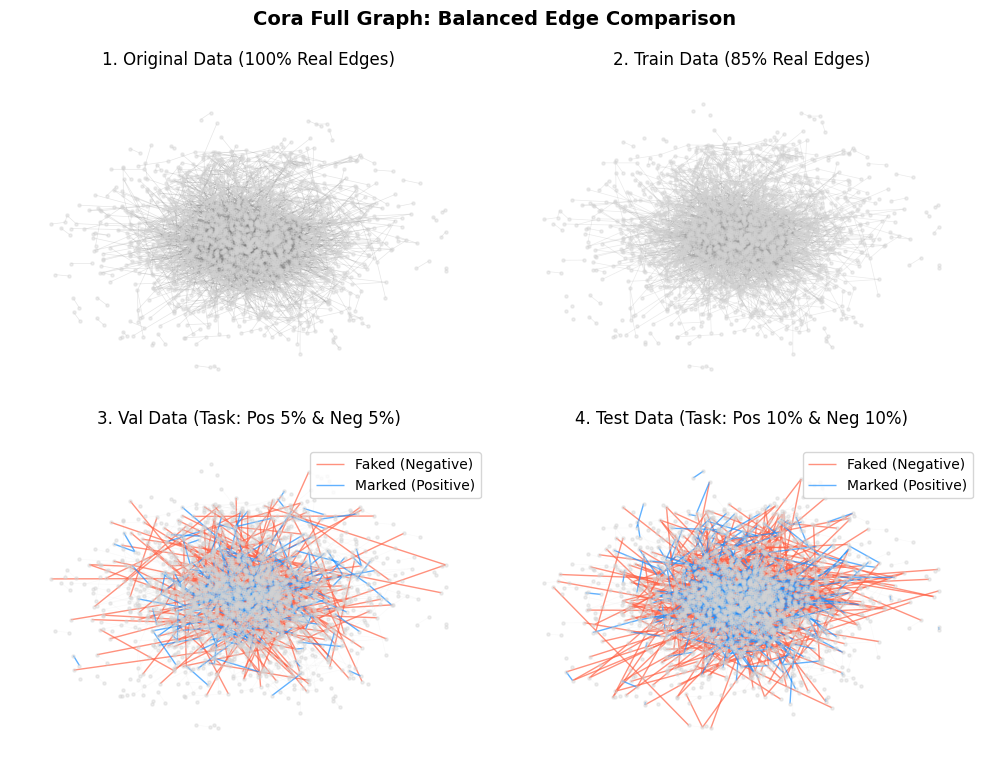

In [5]:
import networkx as nx

# converts PyTorch edge index tensors into a Python Set to remove duplicates
def get_edge_set(index_tensor):
    index_tensor = index_tensor.cpu()
    edges = set()
    for i in range(index_tensor.shape[1]):
        u, v = index_tensor[0, i].item(), index_tensor[1, i].item()
        edges.add(tuple(sorted((u, v))))
    return edges

# Preparing Edge Data
train_edges = get_edge_set(train_data.edge_index)
val_pos = get_edge_set(val_data.pos_edge_label_index)
test_pos = get_edge_set(test_data.pos_edge_label_index)
all_real_edges = train_edges | val_pos | test_pos 

val_neg = get_edge_set(val_data.neg_edge_label_index)
test_neg = get_edge_set(test_data.neg_edge_label_index)

# Graph Setup & Layout Calculation
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Cora Full Graph: Balanced Edge Comparison", fontsize=14, fontweight='bold')

G_full = nx.Graph()
G_full.add_nodes_from(range(train_data.num_nodes))
G_full.add_edges_from(list(all_real_edges))

# Computes the spring layout coordinates for all nodes.
pos = nx.spring_layout(G_full, k=0.1, iterations=20, seed=42)

# Visualization Drawing Function
def draw_viz_balanced(ax, title, base_edges, marked=None, faked=None, b_color='#E0E0E0', b_width=0.4):
    ax.set_title(title, fontsize=12, pad=15)
    
    # nodes
    nx.draw_networkx_nodes(G_full, pos, ax=ax, node_size=5, node_color='lightgray', alpha=0.4)
    
    # 1. edges
    nx.draw_networkx_edges(G_full, pos, ax=ax, edgelist=list(base_edges), 
                           edge_color=b_color, width=b_width, alpha=0.2)
    
    # 2. Fake Edges 
    if faked:
        nx.draw_networkx_edges(G_full, pos, ax=ax, edgelist=list(faked), 
                               edge_color='tomato', width=1.0, alpha=0.7, label='Faked (Negative)')
    
    # 3. Real Edges 
    if marked:
        nx.draw_networkx_edges(G_full, pos, ax=ax, edgelist=list(marked), 
                               edge_color='dodgerblue', width=1.0, alpha=0.7, label='Marked (Positive)')
    
    if marked or faked:
        leg = ax.legend(loc='upper right', markerscale=5, fontsize=10)
        for line in leg.get_lines():
            line.set_linewidth(1.0)
            
    ax.axis('off')

# Execution and Display
draw_viz_balanced(axes[0, 0], "1. Original Data (100% Real Edges)", all_real_edges, b_color='gray', b_width=0.5)
draw_viz_balanced(axes[0, 1], "2. Train Data (85% Real Edges)", train_edges, b_color='#999999', b_width=0.5)
draw_viz_balanced(axes[1, 0], "3. Val Data (Task: Pos 5% & Neg 5%)", train_edges, val_pos, val_neg)
draw_viz_balanced(axes[1, 1], "4. Test Data (Task: Pos 10% & Neg 10%)", train_edges, test_pos, test_neg)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

# Fake edges tend to be longer as they randomly connect distant nodes.

In [6]:
# VGAE (Variational Graph Autoencoder) Architecture

from torch_geometric.nn import GCNConv, VGAE

class Encoder(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        # First shared GCN layer extracting features
        self.conv1 = GCNConv(dim_in, 2 * dim_out)

        # Second layers branching out to output Mean (mu) and Standard Deviation (logstd)
        self.conv_mu = GCNConv(2 * dim_out, dim_out)
        self.conv_logstd = GCNConv(2 * dim_out, dim_out)

    def forward(self, x, edge_index):
        # Pass features through the first GCN layer and apply ReLU activation
        x = self.conv1(x, edge_index).relu()

        # Return the parameters of the latent distribution
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

# Instantiate the VGAE model wrapping our custom Encoder
# 16 is the latent dimension size (dim_out)
model = VGAE(Encoder(cora_dataset.num_features, 16)).to(device)

# Set up the Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [7]:
# Training & Testing Functions

def train():
    model.train() # Set model to training mode
    optimizer.zero_grad() # Clear previous gradients
    
    # Encode the training graph into latent vectors (z)
    z = model.encode(train_data.x, train_data.edge_index)
    
    # Calculate the total loss: 
    # Reconstruction Loss (training with positive and negative edges) + 
    # Kullback-Leibler Divergence Loss (regularizing the distribution)
    loss = model.recon_loss(z, train_data.pos_edge_label_index) + (1 / train_data.num_nodes) * model.kl_loss()
    
    loss.backward() # Compute gradients
    optimizer.step() # Update weights
    
    return float(loss)

@torch.no_grad()
def test(data):
    model.eval() # Set model to evaluation mode
    
    # Encode the graph
    z = model.encode(data.x, data.edge_index)
    
    # Test the model by evaluating its ability to distinguish between 
    # true edges (pos_edge_label_index) and non-existent edges (neg_edge_label_index)
    # Returns AUC (Area Under ROC Curve) and Average Precision
    return model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)

In [8]:
# Training Loop & Final Inference

for epoch in range(601):
    loss = train()
    # Validate the model using the test_data (in strict practice, val_data should be used here)
    val_auc, val_ap = test(test_data)
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch:>2} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}') 

# [Caption] Final evaluation on the test set
test_auc, test_ap = test(test_data) 
print(f'Test AUC: {test_auc:.4f} | Test AP {test_ap:.4f}')

Epoch  0 | Loss: 3.5174 | Val AUC: 0.7031 | Val AP: 0.7288
Epoch 100 | Loss: 1.1177 | Val AUC: 0.7539 | Val AP: 0.7562
Epoch 200 | Loss: 1.0060 | Val AUC: 0.8460 | Val AP: 0.8526
Epoch 300 | Loss: 0.9564 | Val AUC: 0.8744 | Val AP: 0.8802
Epoch 400 | Loss: 0.9063 | Val AUC: 0.8980 | Val AP: 0.9016
Epoch 500 | Loss: 0.9011 | Val AUC: 0.9035 | Val AP: 0.9072
Epoch 600 | Loss: 0.8960 | Val AUC: 0.9009 | Val AP: 0.9076
Test AUC: 0.9009 | Test AP 0.9076


In [9]:
# Reconstructing the Adjacency Matrix

# Get the final latent embeddings (z) for all nodes
z = model.encode(test_data.x, test_data.edge_index) 

# Reconstruct the probability of edges between all node pairs
# z @ z.T is the dot product of the node embeddings
# torch.sigmoid squashes the results between 0 and 1, representing the probability of a link
Ahat = torch.sigmoid(z @ z.T)

# probability map of connections (Nodes: 2708*2708 matrix)
print(Ahat)
print()

# Threshold
threshold = 0.5

# Edge? True = 1, False = 0
predicted_edges_binary = (Ahat > threshold).float()

print(predicted_edges_binary)
# diagonal = 1, self-loop

tensor([[0.8233, 0.2342, 0.7396,  ..., 0.7067, 0.7827, 0.8236],
        [0.2342, 0.8929, 0.5602,  ..., 0.3057, 0.3996, 0.3090],
        [0.7396, 0.5602, 0.8842,  ..., 0.5615, 0.8373, 0.8436],
        ...,
        [0.7067, 0.3057, 0.5615,  ..., 0.7356, 0.6601, 0.6812],
        [0.7827, 0.3996, 0.8373,  ..., 0.6601, 0.8325, 0.8466],
        [0.8236, 0.3090, 0.8436,  ..., 0.6812, 0.8466, 0.8731]],
       grad_fn=<SigmoidBackward0>)

tensor([[1., 0., 1.,  ..., 1., 1., 1.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 0., 1.,  ..., 1., 1., 1.],
        [1., 0., 1.,  ..., 1., 1., 1.],
        [1., 0., 1.,  ..., 1., 1., 1.]])


# 2. Subgraph-based (SEAL) Link Prediction
- SEAL (Subgraphs, Embeddings, and Attributes for Link prediction)

In [10]:
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.sparse.csgraph import shortest_path

import torch.nn.functional as F
from torch.nn import Conv1d, MaxPool1d, Linear, Dropout, BCEWithLogitsLoss

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, aggr
from torch_geometric.utils import k_hop_subgraph, to_scipy_sparse_matrix

In [11]:
# Load Cora dataset
transform = RandomLinkSplit(num_val=0.05, num_test=0.1, is_undirected=True, split_labels=True)
dataset = Planetoid('.', name='Cora', transform=transform)
train_data, val_data, test_data = dataset[0]
train_data

Data(x=[2708, 1433], edge_index=[2, 8976], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], pos_edge_label=[4488], pos_edge_label_index=[2, 4488], neg_edge_label=[4488], neg_edge_label_index=[2, 4488])

In [12]:
def seal_processing(dataset, edge_label_index, y):
    data_list = []

    for src, dst in edge_label_index.t().tolist():
        sub_nodes, sub_edge_index, mapping, _ = k_hop_subgraph([src, dst], 2, dataset.edge_index, relabel_nodes=True)
        src, dst = mapping.tolist()

        # Remove target link from the subgraph
        mask1 = (sub_edge_index[0] != src) | (sub_edge_index[1] != dst)
        mask2 = (sub_edge_index[0] != dst) | (sub_edge_index[1] != src)
        sub_edge_index = sub_edge_index[:, mask1 & mask2]

        # Double-radius node labeling (DRNL)
        src, dst = (dst, src) if src > dst else (src, dst)
        adj = to_scipy_sparse_matrix(sub_edge_index, num_nodes=sub_nodes.size(0)).tocsr()

        idx = list(range(src)) + list(range(src + 1, adj.shape[0]))
        adj_wo_src = adj[idx, :][:, idx]

        idx = list(range(dst)) + list(range(dst + 1, adj.shape[0]))
        adj_wo_dst = adj[idx, :][:, idx]

        # Calculate the distance between every node and the source target node
        d_src = shortest_path(adj_wo_dst, directed=False, unweighted=True, indices=src)
        d_src = np.insert(d_src, dst, 0, axis=0)
        d_src = torch.from_numpy(d_src)

        # Calculate the distance between every node and the destination target node
        d_dst = shortest_path(adj_wo_src, directed=False, unweighted=True, indices=dst-1)
        d_dst = np.insert(d_dst, src, 0, axis=0)
        d_dst = torch.from_numpy(d_dst)

        # Calculate the label z for each node
        dist = d_src + d_dst
        z = 1 + torch.min(d_src, d_dst) + dist // 2 * (dist // 2 + dist % 2 - 1)
        z[src], z[dst], z[torch.isnan(z)] = 1., 1., 0.
        z = z.to(torch.long)

        # Concatenate node features and one-hot encoded node labels (with a fixed number of classes)
        node_labels = F.one_hot(z, num_classes=200).to(torch.float)
        node_emb = dataset.x[sub_nodes]
        node_x = torch.cat([node_emb, node_labels], dim=1)

        # Create data object
        data = Data(x=node_x, z=z, edge_index=sub_edge_index, y=y)
        data_list.append(data)

    return data_list

In [13]:
# Enclosing subgraphs extraction
train_pos_data_list = seal_processing(train_data, train_data.pos_edge_label_index, 1)
train_neg_data_list = seal_processing(train_data, train_data.neg_edge_label_index, 0)

val_pos_data_list = seal_processing(val_data, val_data.pos_edge_label_index, 1)
val_neg_data_list = seal_processing(val_data, val_data.neg_edge_label_index, 0)

test_pos_data_list = seal_processing(test_data, test_data.pos_edge_label_index, 1)
test_neg_data_list = seal_processing(test_data, test_data.neg_edge_label_index, 0)
train_neg_data_list[:2]

[Data(x=[34, 1633], edge_index=[2, 102], y=0, z=[34]),
 Data(x=[28, 1633], edge_index=[2, 80], y=0, z=[28])]

In [14]:
train_dataset = train_pos_data_list + train_neg_data_list
val_dataset = val_pos_data_list + val_neg_data_list
test_dataset = test_pos_data_list + test_neg_data_list

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

train_dataset[:2], train_loader

([Data(x=[147, 1633], edge_index=[2, 454], y=1, z=[147]),
  Data(x=[70, 1633], edge_index=[2, 202], y=1, z=[70])],
 <torch_geometric.loader.dataloader.DataLoader at 0x795786861c10>)

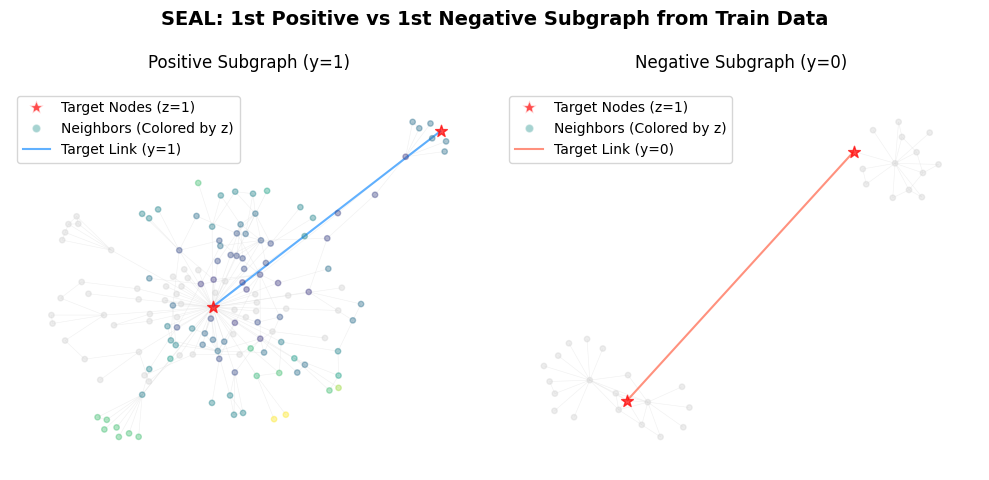

In [18]:
import networkx as nx
from matplotlib.lines import Line2D

def visualize_processed_seal_data(data_pos, data_neg):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    fig.suptitle("SEAL: 1st Positive vs 1st Negative Subgraph from Train Data", 
                 fontsize=14, fontweight='bold', y=0.98)

    def draw_single_data(ax, data, title):
        G = nx.Graph()
        G.add_edges_from(data.edge_index.t().tolist())
        for i in range(data.num_nodes):
            G.add_node(i)
            
        pos = nx.spring_layout(G, seed=42)

        z_labels = data.z.numpy()
        target_nodes = [i for i, z in enumerate(z_labels) if z == 1]
        other_nodes = [i for i, z in enumerate(z_labels) if z != 1]

        cmap = plt.cm.get_cmap('viridis')
        max_z = max(z_labels) if len(z_labels) > 0 else 2
        other_colors = [cmap(z / max_z) if z > 0 else 'lightgray' for z in z_labels[other_nodes]]

        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=other_nodes, 
                               node_color=other_colors, node_size=15, alpha=0.4)

        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#E0E0E0', width=0.4, alpha=0.5)

        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=target_nodes, 
                               node_color='red', node_shape='*', node_size=80, alpha=0.7)

        y_val = data.y.item() if torch.is_tensor(data.y) else data.y

        if len(target_nodes) >= 2:
            src, dst = target_nodes[0], target_nodes[1]
            edge_color = 'dodgerblue' if y_val == 1 else 'tomato'
            nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(src, dst)], 
                                   edge_color=edge_color, style='solid', width=1.5, alpha=0.7)

        ax.set_title(title, fontsize=12, pad=15)
        ax.axis('off')

        legend_elements = [
            Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=10, alpha=0.7, label='Target Nodes (z=1)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(0.5), markersize=6, alpha=0.4, label='Neighbors (Colored by z)'),
            Line2D([0], [0], color=edge_color, lw=1.5, alpha=0.7, linestyle='solid', label=f'Target Link (y={y_val})')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    y_pos = data_pos.y.item() if torch.is_tensor(data_pos.y) else data_pos.y
    y_neg = data_neg.y.item() if torch.is_tensor(data_neg.y) else data_neg.y

    draw_single_data(axes[0], data_pos, f"Positive Subgraph (y={y_pos})")
    draw_single_data(axes[1], data_neg, f"Negative Subgraph (y={y_neg})")

    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    plt.show()

visualize_processed_seal_data(train_pos_data_list[0], train_neg_data_list[0])

In [16]:
class DGCNN(torch.nn.Module):
    def __init__(self, dim_in, k=30):
        super().__init__()

        # GCN layers
        self.gcn1 = GCNConv(dim_in, 32)
        self.gcn2 = GCNConv(32, 32)
        self.gcn3 = GCNConv(32, 32)
        self.gcn4 = GCNConv(32, 1)

        # Global sort pooling
        self.global_pool = aggr.SortAggregation(k=k)

        # Convolutional layers
        self.conv1 = Conv1d(1, 16, 97, 97)
        self.conv2 = Conv1d(16, 32, 5, 1)
        self.maxpool = MaxPool1d(2, 2)

        # Dense layers
        self.linear1 = Linear(352, 128)
        self.dropout = Dropout(0.5)
        self.linear2 = Linear(128, 1)

    def forward(self, x, edge_index, batch):
        # 1. Graph Convolutional Layers
        h1 = self.gcn1(x, edge_index).tanh()
        h2 = self.gcn2(h1, edge_index).tanh()
        h3 = self.gcn3(h2, edge_index).tanh()
        h4 = self.gcn4(h3, edge_index).tanh()
        h = torch.cat([h1, h2, h3, h4], dim=-1)

        # 2. Global sort pooling
        h = self.global_pool(h, batch)

        # 3. Traditional convolutional and dense layers
        h = h.view(h.size(0), 1, h.size(-1))
        h = self.conv1(h).relu()
        h = self.maxpool(h)
        h = self.conv2(h).relu()
        h = h.view(h.size(0), -1)
        h = self.linear1(h).relu()
        h = self.dropout(h)
        h = self.linear2(h).sigmoid()

        return h

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DGCNN(train_dataset[0].num_features).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)
criterion = BCEWithLogitsLoss()

def train():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out.view(-1), data.y.to(torch.float))
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs

    return total_loss / len(train_dataset)

@torch.no_grad()
def test(loader):
    model.eval()
    y_pred, y_true = [], []

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        y_pred.append(out.view(-1).cpu())
        y_true.append(data.y.view(-1).cpu().to(torch.float))

    auc = roc_auc_score(torch.cat(y_true), torch.cat(y_pred))
    ap = average_precision_score(torch.cat(y_true), torch.cat(y_pred))

    return auc, ap

for epoch in range(31):
    loss = train()
    val_auc, val_ap = test(val_loader)
    print(f'Epoch {epoch:>2} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}')

test_auc, test_ap = test(test_loader)
print(f'Test AUC: {test_auc:.4f} | Test AP {test_ap:.4f}')

Epoch  0 | Loss: 0.6960 | Val AUC: 0.8317 | Val AP: 0.8230
Epoch  1 | Loss: 0.6202 | Val AUC: 0.8528 | Val AP: 0.8699
Epoch  2 | Loss: 0.5894 | Val AUC: 0.8569 | Val AP: 0.8796
Epoch  3 | Loss: 0.5819 | Val AUC: 0.8567 | Val AP: 0.8812
Epoch  4 | Loss: 0.5782 | Val AUC: 0.8652 | Val AP: 0.8887
Epoch  5 | Loss: 0.5755 | Val AUC: 0.8631 | Val AP: 0.8867
Epoch  6 | Loss: 0.5733 | Val AUC: 0.8712 | Val AP: 0.8891
Epoch  7 | Loss: 0.5713 | Val AUC: 0.8743 | Val AP: 0.8931
Epoch  8 | Loss: 0.5692 | Val AUC: 0.8736 | Val AP: 0.8921
Epoch  9 | Loss: 0.5671 | Val AUC: 0.8706 | Val AP: 0.8784
Epoch 10 | Loss: 0.5652 | Val AUC: 0.8763 | Val AP: 0.8830
Epoch 11 | Loss: 0.5617 | Val AUC: 0.8799 | Val AP: 0.8860
Epoch 12 | Loss: 0.5580 | Val AUC: 0.8826 | Val AP: 0.8876
Epoch 13 | Loss: 0.5551 | Val AUC: 0.8835 | Val AP: 0.8884
Epoch 14 | Loss: 0.5536 | Val AUC: 0.8823 | Val AP: 0.8888
Epoch 15 | Loss: 0.5514 | Val AUC: 0.8818 | Val AP: 0.8884
Epoch 16 | Loss: 0.5512 | Val AUC: 0.8834 | Val AP: 0.88